From https://eloy.readthedocs.io/en/latest/photometry/

In [69]:

from astropy.io import fits
from dateutil import parser
from glob import glob
from datetime import datetime

reference_file = "output/stack_image.fits"

images = glob("data/*.fits.fz")

# get observation time from FITS header (SCI extension)
def observation_time(file):

    sci_header = fits.getheader(file, extname='sci')
    date_str = sci_header["DATE-OBS"]
    return parser.parse(date_str)


# order by observation time
images = sorted(images, key=lambda file: observation_time(file))
#images = images[0:5]  # limit to first 5 images for testing
images = images[0:22]


In [70]:
print(images)

['data/NxAst-pandorahatp11multibandseries_gp_2461211d71334542_20260619_1a677_25_baron.fits.fz', 'data/NxAst-pandorahatp11multibandseries_gp_2461211d71409833_20260619_1a670_25_baron.fits.fz', 'data/NxAst-pandorahatp11multibandseries_gp_2461211d71485766_20260619_1a664_25_baron.fits.fz', 'data/NxAst-pandorahatp11multibandseries_gp_2461211d71561668_20260619_1a657_25_baron.fits.fz', 'data/NxAst-pandorahatp11multibandseries_gp_2461211d71638440_20260619_1a651_25_baron.fits.fz', 'data/NxAst-pandorahatp11multibandseries_gp_2461211d71716235_20260619_1a642_25_baron.fits.fz', 'data/NxAst-pandorahatp11multibandseries_gp_2461211d71793986_20260619_1a636_25_baron.fits.fz', 'data/NxAst-pandorahatp11multibandseries_gp_2461211d71872130_20260619_1a629_25_baron.fits.fz', 'data/NxAst-pandorahatp11multibandseries_gp_2461211d71951702_20260619_1a623_25_baron.fits.fz', 'data/NxAst-pandorahatp11multibandseries_gp_2461211d72031165_20260619_1a617_25_baron.fits.fz', 'data/NxAst-pandorahatp11multibandseries_gp_24612

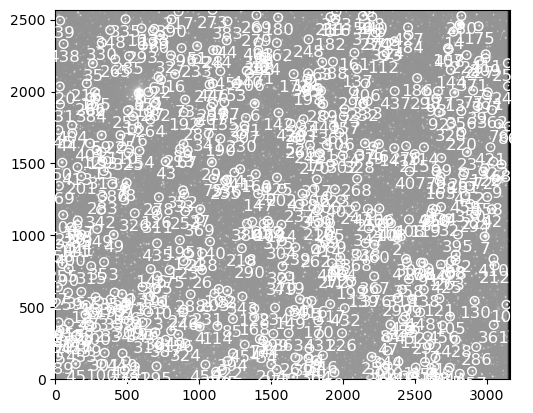

In [71]:
# calibration sequence

import numpy as np

#hot-patch numpy for compatibility with eloy
#np.in1d = np.isin

from eloy import psf, detection, utils

trim = 10
n_stars_align = 12


def calibration_sequence(file):
    # getting data
    data = fits.getdata(file)
    header = fits.getheader(file)

    # trimming
    calibrated_data = data[trim:-trim, trim:-trim]
#    calibrated_data = data

    # detection
    regions = detection.stars_detection(calibrated_data)
    # stars coords and cutouts
    region_coords = np.array([(r.centroid[1], r.centroid[0]) for r in regions])
    cutouts = utils.cutout(calibrated_data, region_coords, (50, 50))

    # epsf modeling
    cutouts_normalized = cutouts / np.nanmax(cutouts, (1, 2))[:, None, None]
    epsf = np.nanmedian(cutouts_normalized, 0)
    psf_params = psf.fit_gaussian(epsf)
    fwhm = psf.gaussian_sigma_to_fwhm * np.mean(
        [psf_params["sigma_x"], psf_params["sigma_y"]]
    )

    del (
        cutouts_normalized,
        data,
        regions,
        cutouts,
        epsf,
        header,
    )

    return calibrated_data, region_coords, fwhm


# and create a calibration sequence from the reference image
import matplotlib.pyplot as plt
from eloy import alignment, viz

ref_data, ref_coords, ref_fwhm = calibration_sequence(reference_file)
ref_reference = alignment.twirl_reference(ref_coords[0:n_stars_align])

ref_header = fits.getheader(reference_file)

plt.imshow(viz.z_scale(ref_data), cmap="Greys_r", origin="lower")
viz.plot_marks(*ref_coords.T, color="w", label=True, ms=30)


In [72]:
# now do the photometry sequence for all images

from tqdm.auto import tqdm
from skimage.transform import AffineTransform
from eloy.ballet import Ballet
from astropy.time import Time
from collections import defaultdict
from eloy import centroid, photometry

n_stars = 100
#relative_apertures_radii = np.linspace(0.1, 5, 40)
relative_aperture_radius = 2.5
cnn = Ballet()

data = defaultdict(list)

for file in tqdm(images):
    calibrated_data, coords, fwhm = calibration_sequence(file)

    # alignment
    R = alignment.rotation_matrix(coords[0:n_stars_align], ref_coords, ref_reference)
    transform = AffineTransform(R)#.inverse
    aligned_coords = transform(ref_coords)[0:n_stars]
    dx, dy = np.median(ref_coords[0:n_stars] - aligned_coords, 0)

    # centroiding
    centroid_coords = centroid.ballet_centroid(calibrated_data, aligned_coords, cnn)
    # aperture photometry
    aperture_radius = relative_aperture_radius * fwhm
    flux = photometry.aperture_photometry(
        calibrated_data, centroid_coords, [aperture_radius]
    )
    flux = np.squeeze(flux)
    
    # annulus background correction
    annulus_radii = aperture_radius, 8 * fwhm
    aperture_area = np.pi * aperture_radius**2
    bkg = photometry.annulus_sigma_clip_median(
        calibrated_data, centroid_coords, *annulus_radii
    )
    bkg = bkg * aperture_area

    # getting data
    header = fits.open(file)[0].header
    data["bkg"].append(bkg)
    data["flux"].append(flux)
    data["fwhm"].append(fwhm)
    
    sci_header = fits.getheader(file, extname='sci')
    date_str = sci_header["DATE-OBS"]
    jd = Time(parser.parse(date_str)).jd

    #jd = Time(parser.parse(header["DATE-OBS"])).jd
    data["time"].append(jd)
    data["dx"].append(dx)
    data["dy"].append(dy)


for k, v in data.items():
    data[k] = np.array(v)


  0%|          | 0/22 [00:00<?, ?it/s]

In [63]:
print(data["flux"].shape)
print(data["flux"])

(44, 100)
[[1144237.60899155 1175394.67074824 1122768.46382949 ...  108504.68271807
   109125.03669696  106419.89580869]
 [1219688.403646   1189742.33891581 1140053.70320339 ...  118881.42999729
   119308.68999999  116527.95376363]
 [1263908.48113572 1201919.88969114 1155255.41704875 ...  122180.37993773
   122722.74636884  119849.8784646 ]
 ...
 [ 465248.44743008  504886.82324678  483083.11525717 ...   77336.15199426
    77320.074817     76339.46877003]
 [ 452159.14208959  516894.35854956  496042.6141643  ...   74808.21741989
    74595.70081099   73702.81459536]
 [ 130287.44241295  549187.38955053  521791.13526957 ...   72683.61143348
    72730.77362806   71717.41012516]]


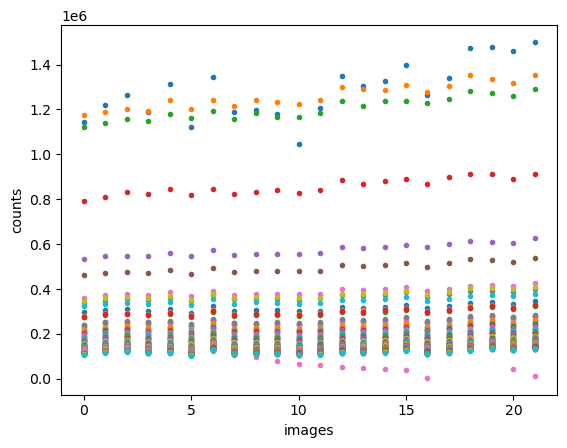

In [73]:
import matplotlib.pyplot as plt

#plot some random photometry data
for i in range(100):
    plt.plot(data["flux"][:, i], ".")
plt.xlabel("images")
_ = plt.ylabel("counts")


Target index is 2
[2378.62021858  982.94808743]
<SkyCoord (ICRS): (ra, dec) in deg
    (297.71352425, 48.08124187)>
<SkyCoord (ICRS): (ra, dec) in deg
    (297.70936374, 48.0808615)>


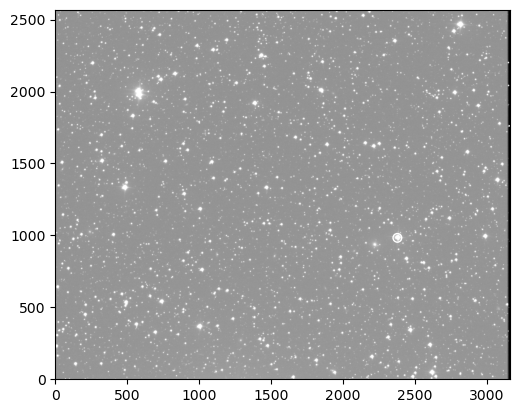

In [74]:
# need to identify the target!
from astroquery.mast import Mast
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS


#transform ref_coords to skycoords
wcs = WCS(ref_header)
centroid_radec = wcs.pixel_to_world(*ref_coords.T)

mast = Mast()
target_radec = mast.resolve_object("HAT-P-11")
target_index = int(target_radec.match_to_catalog_sky(centroid_radec)[0])

print(f"Target index is {target_index}")
print(f"{ref_coords[target_index]}")
print(f"{centroid_radec[target_index]}")
print(f"{target_radec}")

plt.imshow(viz.z_scale(ref_data), cmap="Greys_r", origin="lower")
viz.plot_marks(ref_coords[target_index][0],ref_coords[target_index][1], color="w", ms=30)

target = ref_coords[target_index]


In [76]:
# "In order to perform differential photometry eloy implements the Broeg 2005 algorithm.""

from eloy import flux

# we remove the background from the annulus aperture
fluxes = (data["flux"] - data["bkg"]).T
display(fluxes.shape)

# and perform different photometry
diffs, weights = flux.auto_diff_1d(fluxes, target_index)
display(diffs)
# finally we find the 'optimal' aperture for our target
#best_aperture = flux.optimal_flux(diffs[target_index])
#diff = diffs[best_aperture, target_index]



(100, 22)

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(100, 22))

In [68]:
display(fluxes)
display(diffs)
display(target_index)

array([[1058303.79469428, 1122690.18809056, 1164912.93929816, ...,
         396580.74136215,  386229.32821635,   66771.96158033],
       [1093811.35051485, 1097549.63441918, 1107224.50526561, ...,
         438042.02275242,  452890.19905149,  488280.58643855],
       [1041325.71291717, 1048114.09369705, 1060642.96464823, ...,
         416390.52100715,  432115.6121194 ,  460925.60015969],
       ...,
       [  28731.37504386,   28671.20937538,   29360.36864012, ...,
          11406.5692264 ,   11736.44819817,   12726.08726081],
       [  29283.80661996,   28894.36439486,   29604.60254701, ...,
          11353.94035202,   11438.29711763,   12769.61491939],
       [  26984.03951362,   26638.17127299,   27242.39756652, ...,
          10558.26129811,   10788.75435764,   11972.421245  ]],
      shape=(100, 44))

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(100, 44))

2

In [55]:
display(data["time"])
utils.index_binning(data["time"], 0.005)

array([2461211.71099376, 2461211.71174664, 2461211.71250595,
       2461211.71326494, 2461211.71403264, 2461211.71481057,
       2461211.71558806, 2461211.71636947, 2461211.71716516,
       2461211.71795977, 2461211.71875708, 2461211.71955946,
       2461211.72037567, 2461211.72118284, 2461211.72198685,
       2461211.72280185, 2461211.7236241 , 2461211.72528775,
       2461211.72609825, 2461211.72693186, 2461211.7278259 ,
       2461211.7286673 , 2461211.72954226, 2461211.94205001,
       2461211.94244751, 2461211.94285774, 2461211.94328488,
       2461211.94372329, 2461211.94417138, 2461211.94514953,
       2461211.94563925, 2461211.94708286, 2461211.94758404,
       2461211.94870052, 2461211.9491692 , 2461211.94966759,
       2461211.95016284, 2461211.95107626, 2461211.95157045,
       2461211.95264765, 2461211.95376689, 2461211.95616596,
       2461211.9567113 , 2461211.9586886 ])

[array([0, 1, 2, 3, 4, 5, 6]),
 array([ 7,  8,  9, 10, 11, 12]),
 array([13, 14, 15, 16, 17]),
 array([18, 19, 20, 21, 22]),
 array([23, 24, 25, 26, 27, 28, 29, 30]),
 array([31, 32, 33, 34, 35, 36]),
 array([37, 38, 39, 40]),
 array([41, 42, 43])]

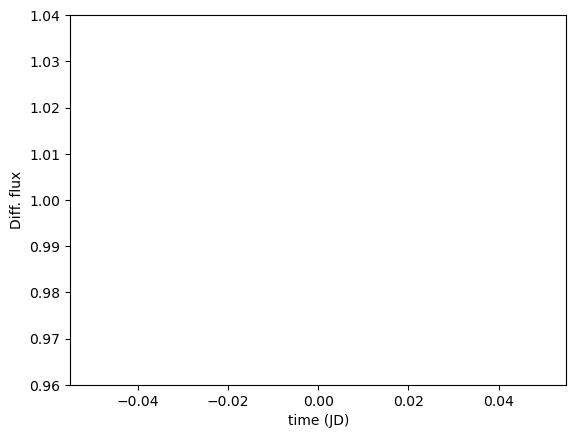

In [56]:
idxs = utils.index_binning(data["time"], 0.005)
binned_time = [data["time"][i].mean() for i in idxs]
binned_diff = [diffs[i].mean() for i in idxs]
binned_error = [diffs[i].std() / np.sqrt(len(i)) for i in idxs]


plt.plot(data["time"], diffs[target_index, :], ".", c="0.8")
plt.errorbar(binned_time, binned_diff, yerr=binned_error, fmt=".", c="k")
plt.ylim(0.96, 1.04)
plt.xlabel("time (JD)")
_ = plt.ylabel("Diff. flux")


In [57]:
print(fluxes)

[[ 1.07305424e+06  8.78335373e+05  9.73791813e+05 ...  1.56386346e+02
  -1.01086394e+02  5.61641779e+01]
 [ 1.09404593e+06  1.09705761e+06  1.10704853e+06 ...  1.87763735e+02
   4.96311005e+01 -1.10770834e+01]
 [ 1.04170079e+06  1.04800144e+06  1.06102468e+06 ...  3.45453608e+01
  -5.45461120e+01  6.11611878e+01]
 ...
 [ 2.87575327e+04  2.86775589e+04  2.93082080e+04 ...  2.42689030e+01
   5.88175337e+01  8.58223937e+01]
 [ 2.92918203e+04  2.88632209e+04  2.96186457e+04 ...  5.65774446e+01
   7.73445789e+01  6.06384762e+01]
 [ 2.69916327e+04  2.66303867e+04  2.72501374e+04 ...  9.25447363e+02
   1.11405992e+03  5.10170503e+02]]
